In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('merged_data_A_Final_fixed.csv', encoding='utf-8-sig')

df['Tarih'] = pd.to_datetime(df['Tarih'], dayfirst=True)
df['Ay'] = df['Tarih'].dt.month
df['Mevsim'] = df['Ay'].map({
    12:'Kis', 1:'Kis', 2:'Kis',
    3:'Ilkbahar', 4:'Ilkbahar', 5:'Ilkbahar',
    6:'Yaz', 7:'Yaz', 8:'Yaz',
    9:'Sonbahar', 10:'Sonbahar', 11:'Sonbahar'
})

gases = ['PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'NO2 (µg/m3)', 'O3 (µg/m3)', 'SO2 (µg/m3)']

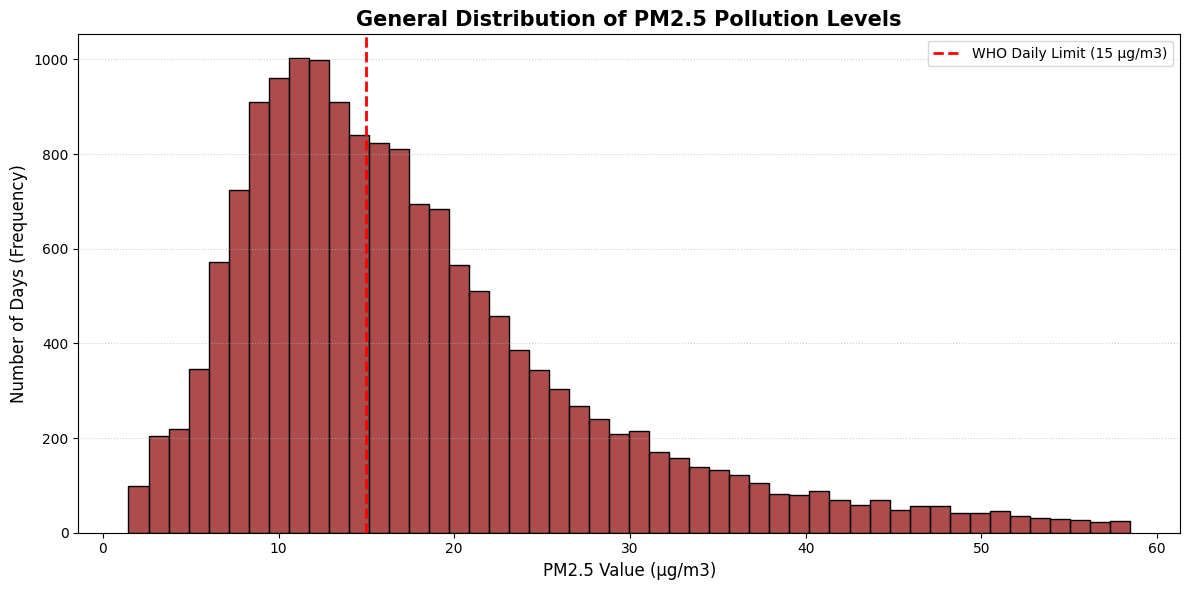

In [2]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='PM2.5 (µg/m3)', bins=50, kde=False, color='darkred', alpha=0.7)

plt.axvline(x=15, color='red', linestyle='--', linewidth=2, label='WHO Daily Limit (15 µg/m3)')


plt.title('General Distribution of PM2.5 Pollution Levels', fontsize=15, fontweight='bold')
plt.xlabel('PM2.5 Value (µg/m3)', fontsize=12)
plt.ylabel('Number of Days (Frequency)', fontsize=12)

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend()
plt.tight_layout()

plt.show()

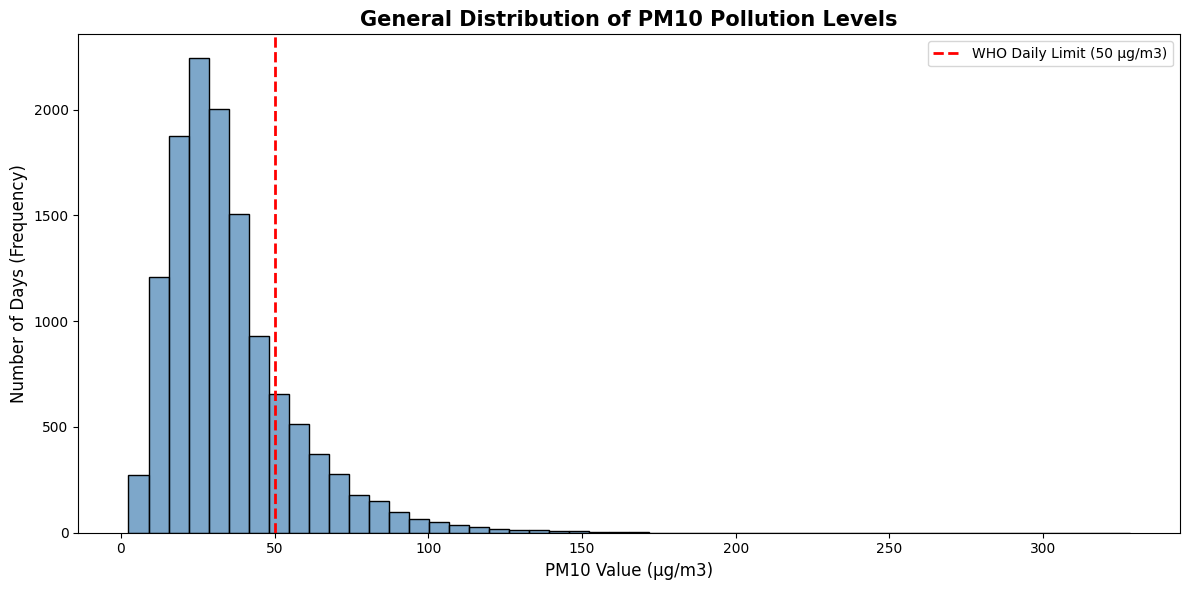

In [3]:
plt.figure(figsize=(12, 6))

sns.histplot(data=df, x='PM10 (µg/m3)', bins=50, kde=False, color='steelblue', alpha=0.7)

plt.axvline(x=50, color='red', linestyle='--', linewidth=2, label='WHO Daily Limit (50 µg/m3)')

plt.title('General Distribution of PM10 Pollution Levels', fontsize=15, fontweight='bold')
plt.xlabel('PM10 Value (µg/m3)', fontsize=12)
plt.ylabel('Number of Days (Frequency)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

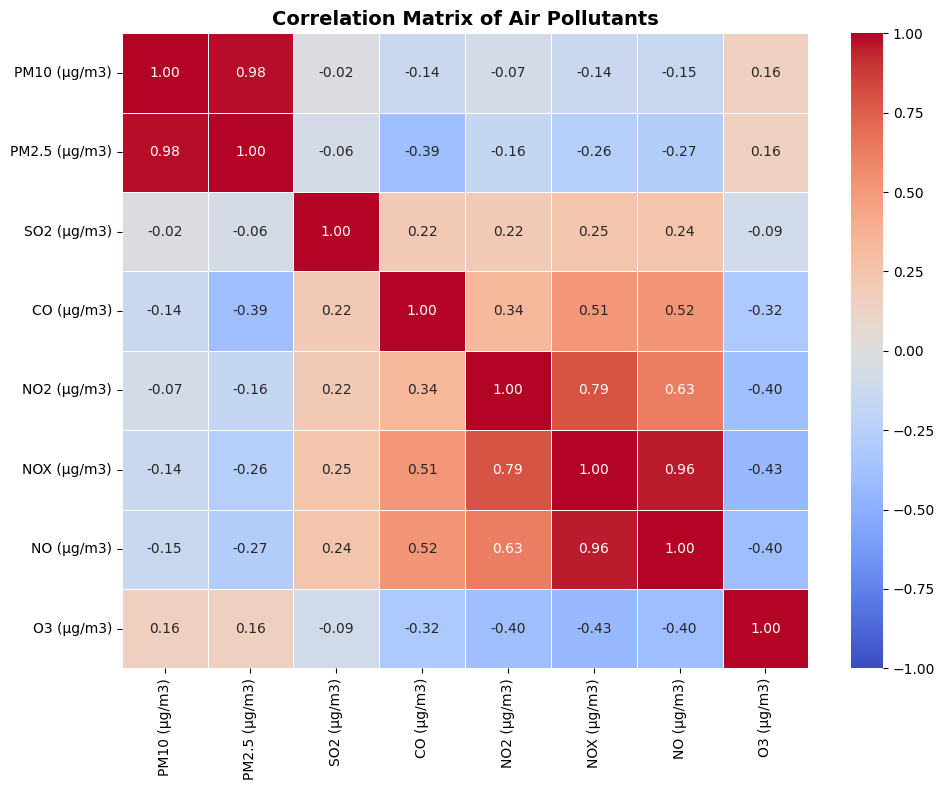

In [4]:
pollution_cols = ['PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'SO2 (µg/m3)', 
                  'CO (µg/m3)', 'NO2 (µg/m3)', 'NOX (µg/m3)', 
                  'NO (µg/m3)', 'O3 (µg/m3)']
df_numeric = df[pollution_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,        
            fmt=".2f",        
            cmap="coolwarm",
            vmin=-1, vmax=1,   
            linewidths=0.5)

plt.title('Correlation Matrix of Air Pollutants', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

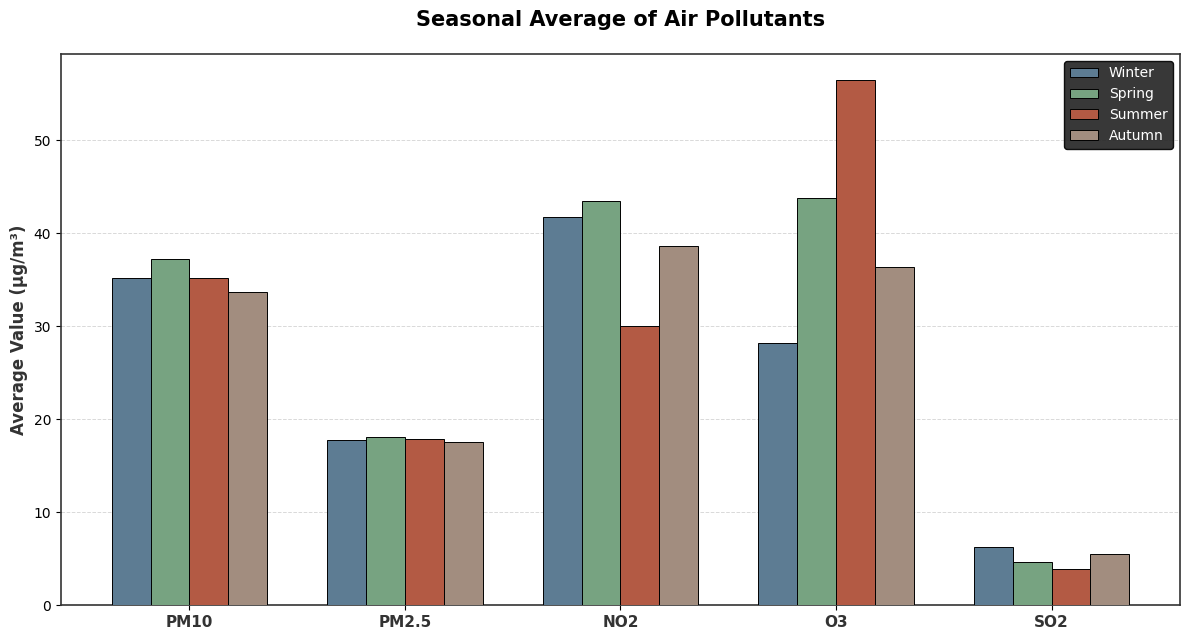

In [6]:

df['Tarih'] = pd.to_datetime(df['Tarih'], dayfirst=True)
df['Ay'] = df['Tarih'].dt.month
df['Mevsim'] = df['Ay'].map({
    12:'Kis', 1:'Kis', 2:'Kis',
    3:'Ilkbahar', 4:'Ilkbahar', 5:'Ilkbahar',
    6:'Yaz', 7:'Yaz', 8:'Yaz',
    9:'Sonbahar', 10:'Sonbahar', 11:'Sonbahar'
})

mevsim_colors = {
    'Kis': '#5D7C93',    
    'Ilkbahar': '#77A381', 
    'Yaz': '#B35A44',    
    'Sonbahar': '#A28D7F'  
}
mevsim_order  = ['Kis', 'Ilkbahar', 'Yaz', 'Sonbahar']
mevsim_labels = {'Kis':'Winter', 'Ilkbahar':'Spring', 'Yaz':'Summer', 'Sonbahar':'Autumn'}

gases  = ['PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'NO2 (µg/m3)', 'O3 (µg/m3)', 'SO2 (µg/m3)']
labels = ['PM10', 'PM2.5', 'NO2', 'O3', 'SO2']

fig, ax = plt.subplots(figsize=(12, 6.5), facecolor='white')
ax.set_facecolor('white')

mev_mean = df.groupby('Mevsim')[gases].mean().reindex(mevsim_order)
x = np.arange(len(labels))
width = 0.18

for i, mev in enumerate(mevsim_order):
    ax.bar(x + i * width, mev_mean.loc[mev, gases], width,
           label=mevsim_labels[mev],
           color=mevsim_colors[mev],
           edgecolor='black',
           linewidth=0.7,
           zorder=3)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(labels, fontsize=11, fontweight='bold', color='#333')
ax.set_ylabel('Average Value (µg/m³)', fontsize=12, fontweight='bold', color='#333')
ax.set_title('Seasonal Average of Air Pollutants', fontsize=15, fontweight='bold', pad=20)

ax.legend(fontsize=10, frameon=True, facecolor='#222222', labelcolor='white',
          edgecolor='black', loc='upper right', framealpha=0.9)

ax.grid(axis='y', color='#D0D0D0', linestyle='--', linewidth=0.7, alpha=0.8, zorder=0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('#333333')
    spine.set_linewidth(1.2)

plt.tight_layout()
plt.show()

In [11]:
df = df.dropna(axis=1, how="all").dropna()
df.describe()

,Tarih,PM10 (µg/m3),PM2.5 (µg/m3),SO2 (µg/m3),CO (µg/m3),NO2 (µg/m3),NOX (µg/m3),NO (µg/m3),O3 (µg/m3),Ay
count,9,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.0
mean,2019-01-20 00:00:00,155.002222,57.857778,4.948889,81.206667,30.406667,42.658889,7.955556,35.697778,1.0
min,2019-01-16 00:00:00,146.380000,57.690000,2.930000,51.070000,18.680000,26.470000,3.820000,27.190000,1.0
25%,2019-01-18 00:00:00,147.820000,57.800000,3.420000,62.230000,20.570000,27.390000,5.630000,29.210000,1.0
50%,2019-01-20 00:00:00,153.980000,57.870000,5.120000,73.900000,33.580000,50.520000,7.400000,31.920000,1.0
75%,2019-01-22 00:00:00,162.080000,57.920000,5.550000,79.890000,39.430000,52.230000,8.920000,42.040000,1.0
max,2019-01-24 00:00:00,166.620000,58.070000,7.570000,165.770000,41.020000,62.970000,15.300000,52.290000,1.0
std,NaN,7.826912,0.121324,1.695866,34.436060,9.454160,14.029014,3.708346,8.912825,0.0


In [27]:
gases = ['PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'NO2 (µg/m3)', 'O3 (µg/m3)', 'SO2 (µg/m3)']

for col in gases:
    df[col] = pd.to_numeric(df[col], errors='coerce')

missing_data = df[gases].isnull().sum()
missing_percent = (missing_data / len(df)) * 100

missing_report = pd.DataFrame({
    'Eksik Sayısı': missing_data,
    'Yüzde (%)': missing_percent.map('{:.2f}%'.format)
})

print("--- EKSİK VERİ ANALİZİ ---")
print(missing_report)
print(f"\nToplam Satır Sayısı: {len(df)}")

--- EKSİK VERİ ANALİZİ ---
               Eksik Sayısı Yüzde (%)
PM10 (µg/m3)           3496    21.80%
PM2.5 (µg/m3)             0     0.00%
NO2 (µg/m3)             202     1.26%
O3 (µg/m3)             5654    35.26%
SO2 (µg/m3)            6732    41.98%

Toplam Satır Sayısı: 16035


In [2]:
df.head()

,İlçe,Tarih,PM10 (µg/m3),PM2.5 (µg/m3),SO2 (µg/m3),CO (µg/m3),NO2 (µg/m3),NOX (µg/m3),NO (µg/m3),O3 (µg/m3),Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16,YilAy
0,Arnavutköy,2019-01-08,328.22,58.46,4.36,97.44,8.47,13.66,2.16,53.69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01
1,Arnavutköy,2019-01-09,310.96,58.45,4.66,NaN,20.91,24.68,2.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01
2,Arnavutköy,2019-01-10,284.83,58.43,4.75,NaN,10.93,14.95,2.19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01
3,Arnavutköy,2019-01-11,238.90,58.28,4.99,230.40,10.07,17.23,4.67,56.34,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01
4,Arnavutköy,2019-01-12,182.01,58.26,5.89,286.65,9.71,17.84,5.27,51.53,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-01


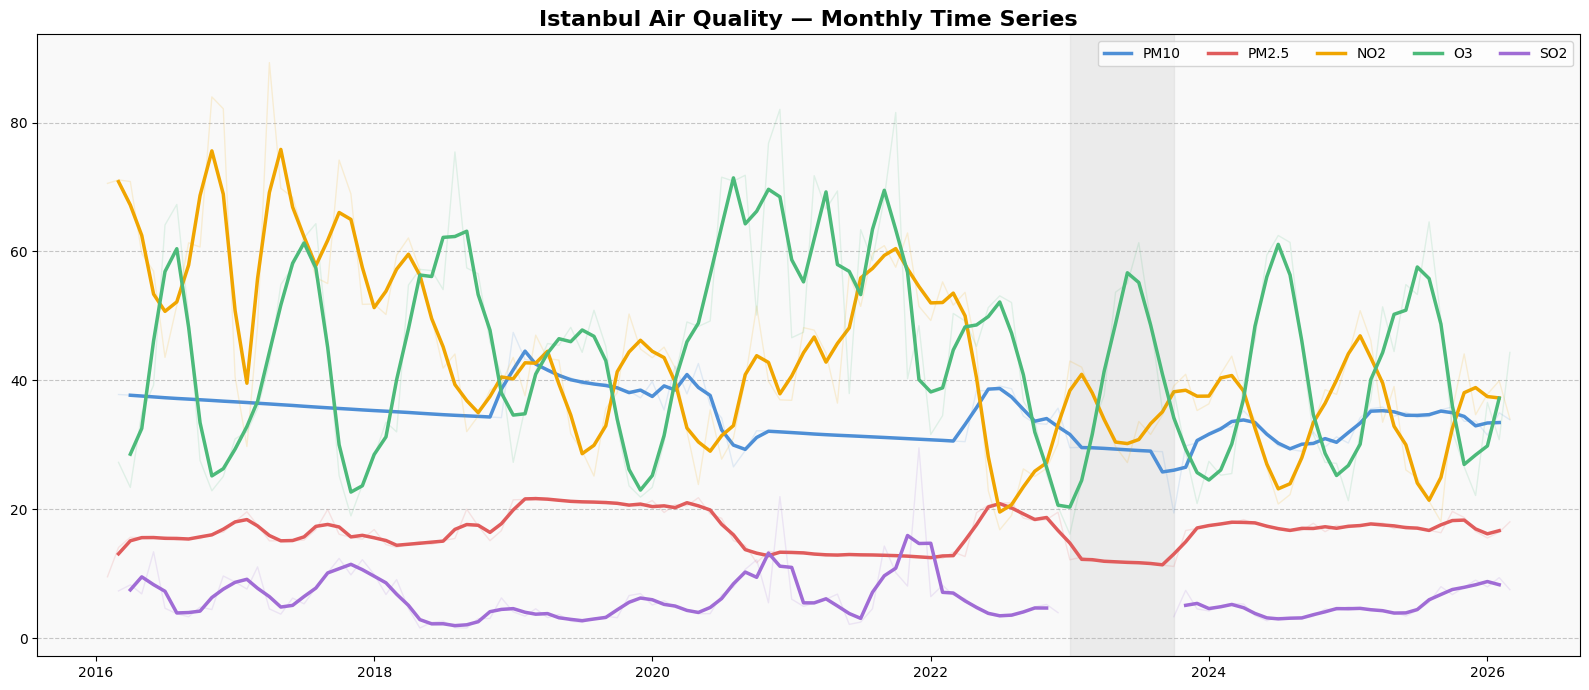

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = pd.read_csv('merged_data_A_Final_fixed.csv', encoding='utf-8-sig')
df['Tarih'] = pd.to_datetime(df['Tarih'], dayfirst=True)
df['YilAy'] = df['Tarih'].dt.to_period('M')

gases  = ['PM10 (µg/m3)', 'PM2.5 (µg/m3)', 'NO2 (µg/m3)', 'O3 (µg/m3)', 'SO2 (µg/m3)']
labels = ['PM10', 'PM2.5', 'NO2', 'O3', 'SO2']
colors = ['#4e8fd6', '#e05c5c', '#f0a500', '#4cba7a', '#a06cd5']

monthly = df.groupby('YilAy')[gases].mean()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(16, 7), facecolor='white')
ax = plt.gca()
ax.set_facecolor('#f9f9f9')

for gas, label, color in zip(gases, labels, colors):
    y = monthly[gas]
    y_roll = y.rolling(3, center=True).mean()
    
    plt.plot(monthly.index, y, color=color, alpha=0.15, linewidth=1)
    plt.plot(monthly.index, y_roll, color=color, linewidth=2.5, label=label)

gap_start = pd.Timestamp('2023-01-01')
gap_end   = pd.Timestamp('2023-10-01')
plt.axvspan(gap_start, gap_end, color='#cccccc', alpha=0.3)

plt.title('Istanbul Air Quality — Monthly Time Series', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', ncol=5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()